In [25]:
import tensorflow as tf
print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.21.0
GPU: []


# 1. SETUP

In [26]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import os

# 2. CONFIG

In [27]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32 # Sesuaikan kemampuan GPU

TRAIN_DIR = "data/processed/train"
VAL_DIR   = "data/processed/validation"
TEST_DIR  = "data/processed/test"

EPOCHS = 30 # Bisa diubah
FINE_TUNE_EPOCHS = 15 # Epoch untuk fine-tuning

INITIAL_LR = 1e-4 # Learning rate di 0.0001
FINE_TUNE_LR = 1e-5 # Learning rate di 0.00001 untuk fine-tuning

# Kontrol training: default jalankan full epoch (tanpa stop otomatis)
USE_EARLY_STOPPING = False
EARLY_STOP_PATIENCE = 7
EARLY_STOP_START_EPOCH = 3

# 3. LOAD DATASET

In [28]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Normalisasi dataset ke rentang [0, 1] sebelum masuk ke model
train_gen = ImageDataGenerator(rescale=1.0 / 255.0)
val_test_gen = ImageDataGenerator(rescale=1.0 / 255.0)

# Membuat generator untuk data train
train_data = train_gen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Membuat generator untuk data validasi
val_data = val_test_gen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Membuat generator untuk data test
test_data = val_test_gen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 560 images belonging to 4 classes.
Found 60 images belonging to 4 classes.


Found 60 images belonging to 4 classes.


# 4. CALLBACK

In [29]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

callbacks = [
    ModelCheckpoint("models/best_model.h5", save_best_only=True),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1,
    ),
]

# EarlyStopping opsional: aktifkan jika ingin hentikan training otomatis
if USE_EARLY_STOPPING:
    callbacks.append(
        EarlyStopping(
            monitor='val_loss',
            patience=EARLY_STOP_PATIENCE,
            start_from_epoch=EARLY_STOP_START_EPOCH,
            restore_best_weights=True,
            verbose=1,
        )
    )

# 5. FUNCTION EVALUASI

In [30]:
def _collect_full_test_set(generator):
    generator.reset()
    x_batches, y_batches = [], []
    for _ in range(len(generator)):
        x_batch, y_batch = next(generator)
        x_batches.append(x_batch)
        y_batches.append(y_batch)

    x_test = np.concatenate(x_batches, axis=0)
    y_true = np.argmax(np.concatenate(y_batches, axis=0), axis=1)
    return x_test, y_true

def evaluate_model(model, model_name):
    print(f"\n=== {model_name} ===")

    # Evaluasi loss/akurasi pada test generator
    test_data.reset()
    loss, acc = model.evaluate(test_data, verbose=0)
    print("Accuracy:", acc)
    print("Loss:", loss)

    # Prediksi menggunakan array penuh agar bentuk tensor konsisten
    x_test, y_true = _collect_full_test_set(test_data)
    y_pred = np.argmax(model.predict(x_test, batch_size=BATCH_SIZE, verbose=0), axis=1)

    class_names = [
        name
        for name, _ in sorted(test_data.class_indices.items(), key=lambda item: item[1])
    ]

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

    return acc

# 6. MODEL

## A. MobileNetV2

In [31]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

# Membangun MobileNetV2 sebagai base model
def build_mobilenet():
    input_layer = tf.keras.Input(shape=(224, 224, 3))
    # Data sudah dinormalisasi [0, 1], kembalikan ke [0, 255] sebelum preprocess_input
    x = layers.Lambda(
        lambda t: tf.keras.applications.mobilenet_v2.preprocess_input(t * 255.0)
    )(input_layer)

    base = MobileNetV2(weights='imagenet', include_top=False, input_tensor=x)
    base.trainable = False

    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)

    output = layers.Dense(4, activation='softmax')(x)

    model = models.Model(inputs=input_layer, outputs=output)
    return model, base

## B. EfficientNetB0

In [32]:
from tensorflow.keras.applications import EfficientNetB0

# Membangun EfficientNetB0 sebagai base model
def build_efficientnet():
    input_layer = tf.keras.Input(shape=(224, 224, 3))
    x = layers.Lambda(lambda t: t * 255.0)(input_layer)

    base = EfficientNetB0(weights='imagenet', include_top=False, input_tensor=x)
    base.trainable = False

    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)

    output = layers.Dense(4, activation='softmax')(x)

    model = models.Model(inputs=input_layer, outputs=output)
    return model, base

## C. Hybrid (Feature Fusion)

In [33]:
def build_fusion():
    input_layer = tf.keras.Input(shape=(224, 224, 3))

    # Dataset sudah [0,1], ubah dulu ke [0,255] agar preprocessing backbone sesuai
    mob_in = layers.Lambda(
        lambda t: tf.keras.applications.mobilenet_v2.preprocess_input(t * 255.0)
    )(input_layer)
    eff_in = layers.Lambda(lambda t: t * 255.0)(input_layer)

    base1 = MobileNetV2(weights='imagenet', include_top=False, input_tensor=mob_in)
    base2 = EfficientNetB0(weights='imagenet', include_top=False, input_tensor=eff_in)

    base1.trainable = False
    base2.trainable = False

    x1 = layers.GlobalAveragePooling2D()(base1.output)
    x1 = layers.BatchNormalization()(x1)

    x2 = layers.GlobalAveragePooling2D()(base2.output)
    x2 = layers.BatchNormalization()(x2)

    fusion = layers.concatenate([x1, x2])

    x = layers.Dense(256, activation='relu')(fusion)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    output = layers.Dense(4, activation='softmax')(x)

    model = models.Model(inputs=input_layer, outputs=output)
    return model, base1, base2

# 7. Training Function (2 Tahap)

In [34]:
def train_model(model, base_model=None):
    # Tahap 1
    model.compile(
        optimizer=tf.keras.optimizers.Adam(INITIAL_LR),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    model.fit(
        train_data,
        validation_data=val_data,
        epochs=EPOCHS,
        callbacks=callbacks
    )

    # Tahap 2 (Fine-tuning)
    if base_model is not None:
        base_model.trainable = True
        for layer in base_model.layers[:-80]:
            layer.trainable = False
        for layer in base_model.layers[-80:]:
            if not isinstance(layer, tf.keras.layers.BatchNormalization):
                layer.trainable = True

    model.compile(
        optimizer=tf.keras.optimizers.Adam(FINE_TUNE_LR),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    model.fit(
        train_data,
        validation_data=val_data,
        epochs=FINE_TUNE_EPOCHS,
        callbacks=callbacks
    )

    return model

# 8. Train & Evaluasi Model

## A. MobileNetV2

C:\Users\rifqi\AppData\Local\Temp\ipykernel_5440\528472138.py:12: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNetV2(weights='imagenet', include_top=False, input_tensor=x)


Epoch 1/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 592ms/step - accuracy: 0.3123 - loss: 1.9866

18/18 ━━━━━━━━━━━━━━━━━━━━ 18s 775ms/step - accuracy: 0.3446 - loss: 1.8722 - val_accuracy: 0.6167 - val_loss: 1.1058 - learning_rate: 1.0000e-04
Epoch 2/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step - accuracy: 0.4151 - loss: 1.4472

18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 343ms/step - accuracy: 0.4536 - loss: 1.3491 - val_accuracy: 0.7167 - val_loss: 0.9033 - learning_rate: 1.0000e-04
Epoch 3/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step - accuracy: 0.5635 - loss: 1.0825

18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 339ms/step - accuracy: 0.5714 - loss: 1.0571 - val_accuracy: 0.7667 - val_loss: 0.7828 - learning_rate: 1.0000e-04
Epoch 4/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step - accuracy: 0.6159 - loss: 0.9808

...

18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 355ms/step - accuracy: 0.9054 - loss: 0.2420 - val_accuracy: 0.8667 - val_loss: 0.3707 - learning_rate: 1.0000e-04
Epoch 27/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - accuracy: 0.9017 - loss: 0.2464

18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 348ms/step - accuracy: 0.9089 - loss: 0.2308 - val_accuracy: 0.8667 - val_loss: 0.3643 - learning_rate: 1.0000e-04
Epoch 28/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step - accuracy: 0.9257 - loss: 0.2178

18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 345ms/step - accuracy: 0.9286 - loss: 0.2201 - val_accuracy: 0.8667 - val_loss: 0.3635 - learning_rate: 1.0000e-04
Epoch 29/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - accuracy: 0.9202 - loss: 0.1946

18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 346ms/step - accuracy: 0.9250 - loss: 0.2014 - val_accuracy: 0.8667 - val_loss: 0.3615 - learning_rate: 1.0000e-04
Epoch 30/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step - accuracy: 0.9405 - loss: 0.1680

18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 344ms/step - accuracy: 0.9339 - loss: 0.1858 - val_accuracy: 0.8667 - val_loss: 0.3604 - learning_rate: 1.0000e-04
Epoch 1/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.6429 - loss: 0.9244 - val_accuracy: 0.8500 - val_loss: 0.3737 - learning_rate: 1.0000e-05
Epoch 2/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 17s 922ms/step - accuracy: 0.7286 - loss: 0.7284 - val_accuracy: 0.8333 - val_loss: 0.3840 - learning_rate: 1.0000e-05
Epoch 3/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 834ms/step - accuracy: 0.7251 - loss: 0.6849
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
18/18 ━━━━━━━━━━━━━━━━━━━━ 16s 871ms/step - accuracy: 0.7018 - loss: 0.7569 - val_accuracy: 0.8333 - val_loss: 0.3870 - learning_rate: 1.0000e-05
Epoch 4/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 633ms/step - accuracy: 0.7607 - loss: 0.6251 - val_accuracy: 0.8000 - val_loss: 0.3929 - learning_rate: 5.0000e-06
Epoch 5/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 605ms/step - accuracy: 0.7625 - loss:

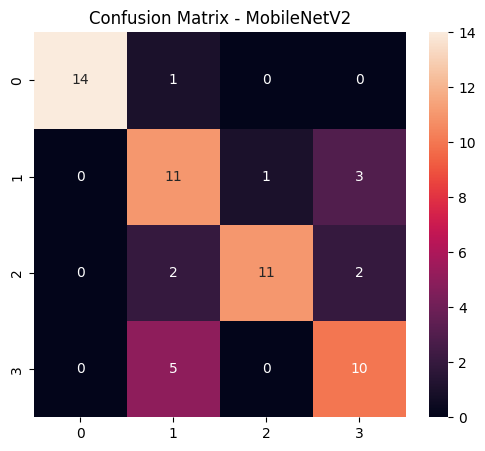

In [35]:
model_m, base_m = build_mobilenet()
model_m = train_model(model_m, base_m)
acc_m = evaluate_model(model_m, "MobileNetV2")

## B. EfficientNetB0

Epoch 1/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 21s 652ms/step - accuracy: 0.2964 - loss: 1.9953 - val_accuracy: 0.4167 - val_loss: 1.2571 - learning_rate: 1.0000e-04
Epoch 2/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 467ms/step - accuracy: 0.4286 - loss: 1.4887 - val_accuracy: 0.5833 - val_loss: 1.0948 - learning_rate: 1.0000e-04
Epoch 3/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - accuracy: 0.5571 - loss: 1.2131
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 468ms/step - accuracy: 0.5536 - loss: 1.1861 - val_accuracy: 0.7000 - val_loss: 0.9609 - learning_rate: 1.0000e-04
Epoch 4/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 473ms/step - accuracy: 0.6107 - loss: 1.0301 - val_accuracy: 0.7333 - val_loss: 0.8893 - learning_rate: 5.0000e-05
Epoch 5/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 470ms/step - accuracy: 0.6196 - loss: 0.9545 - val_accuracy: 0.7500 - val_loss: 0.8239 - learning_rate: 5.0000e-05
Epoch 6/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.64

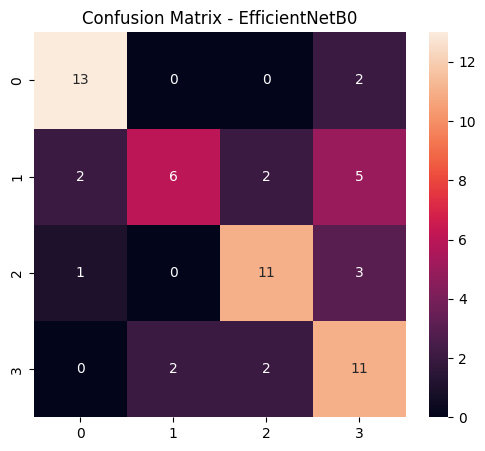

In [36]:
model_e, base_e = build_efficientnet()
model_e = train_model(model_e, base_e)
acc_e = evaluate_model(model_e, "EfficientNetB0")

## C. Hybrid Model

C:\Users\rifqi\AppData\Local\Temp\ipykernel_5440\3286220957.py:10: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base1 = MobileNetV2(weights='imagenet', include_top=False, input_tensor=mob_in)


Epoch 1/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 37s 900ms/step - accuracy: 0.4500 - loss: 1.6114 - val_accuracy: 0.6500 - val_loss: 0.8933 - learning_rate: 1.0000e-04
Epoch 2/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 12s 679ms/step - accuracy: 0.6679 - loss: 0.8941 - val_accuracy: 0.7833 - val_loss: 0.6851 - learning_rate: 1.0000e-04
Epoch 3/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 603ms/step - accuracy: 0.7918 - loss: 0.5992
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
18/18 ━━━━━━━━━━━━━━━━━━━━ 12s 681ms/step - accuracy: 0.7714 - loss: 0.6381 - val_accuracy: 0.8500 - val_loss: 0.5795 - learning_rate: 1.0000e-04
Epoch 4/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 12s 688ms/step - accuracy: 0.8036 - loss: 0.5111 - val_accuracy: 0.8167 - val_loss: 0.5366 - learning_rate: 5.0000e-05
Epoch 5/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 12s 689ms/step - accuracy: 0.8321 - loss: 0.4294 - val_accuracy: 0.8000 - val_loss: 0.5056 - learning_rate: 5.0000e-05
Epoch 6/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 618ms/step - accuracy: 

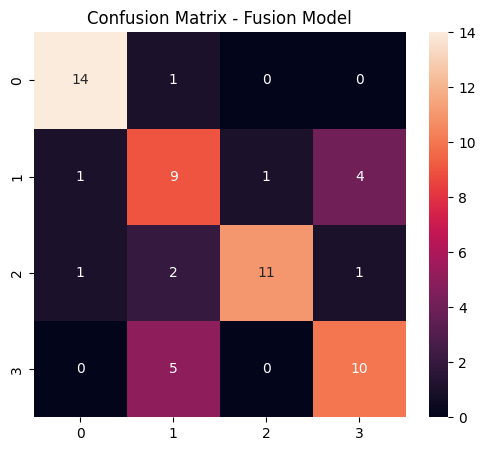

In [37]:
model_f, base1, base2 = build_fusion()

# fine-tune dua backbone
model_f.compile(
    optimizer=tf.keras.optimizers.Adam(INITIAL_LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_f.fit(train_data, validation_data=val_data, epochs=EPOCHS, callbacks=callbacks)

for layer in base1.layers[-30:]:
    layer.trainable = True
for layer in base2.layers[-30:]:
    layer.trainable = True

model_f.compile(
    optimizer=tf.keras.optimizers.Adam(FINE_TUNE_LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_f.fit(train_data, validation_data=val_data, epochs=FINE_TUNE_EPOCHS, callbacks=callbacks)

acc_f = evaluate_model(model_f, "Fusion Model")

# 9. Perbandingan Hasil

In [38]:
print("\n=== HASIL AKHIR ===")
print(f"MobileNetV2   : {acc_m}")
print(f"EfficientNet  : {acc_e}")
print(f"Fusion Model  : {acc_f}")


=== HASIL AKHIR ===
MobileNetV2   : 0.7666666507720947
EfficientNet  : 0.6833333373069763
Fusion Model  : 0.7333333492279053
